
DEUTSCH-JOZSA ALGORITHM - CONSTANT FUNCTION f(x)=0

QUANTUM CIRCUIT
----------------------------------------------------------------------
     ┌───┐     ┌────────┐┌───┐
q_0: ┤ H ├─────┤0       ├┤ H ├
     ├───┤     │        │├───┤
q_1: ┤ H ├─────┤1       ├┤ H ├
     ├───┤     │  Uf(0) │├───┤
q_2: ┤ H ├─────┤2       ├┤ H ├
     ├───┤┌───┐│        │└───┘
q_3: ┤ X ├┤ H ├┤3       ├─────
     └───┘└───┘└────────┘     

MEASUREMENT RESULTS
----------------------------------------------------------------------
Number of input qubits : 3
Number of shots        : 1000
000 count              : 1000
Non-zero count         : 0
P(000)                 : 1.0000
P(non-zero)            : 0.0000
Function classification : CONSTANT

THEORETICAL RESULT
----------------------------------------------------------------------
Theoretical P(000)    : 1.0000
Theoretical P(non-zero): 0.0000

Expected Deutsch-Jozsa result : 000
Verification                  : CORRECT - ALL ZEROS


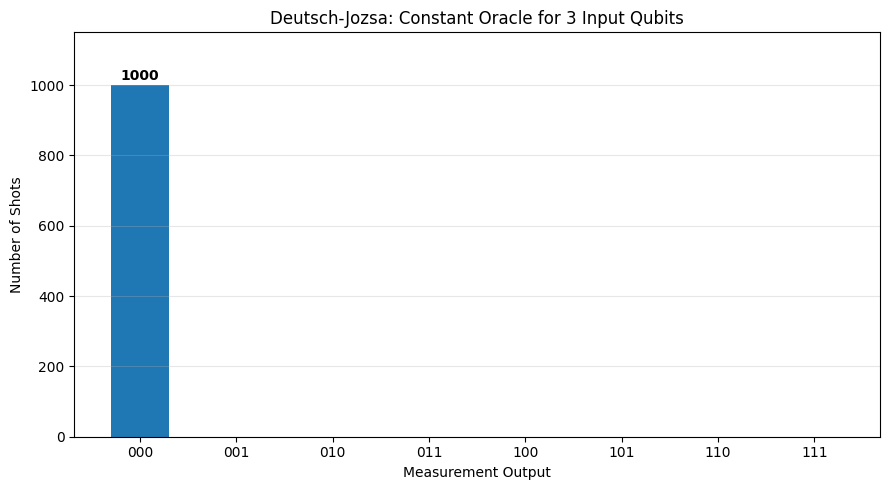

In [2]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt

SHOTS = 1000

# ---------------------------------------------------------
# CONSTANT FUNCTION f(x) = 0
# 3 INPUT QUBITS + 1 ANCILLA
# ---------------------------------------------------------

n = 3

# Create constant oracle
oracle = QuantumCircuit(n + 1, name="Uf(0)")

# For f(x) = 0, no operation is required
oracle_gate = oracle.to_gate()

# ---------------------------------------------------------
# BUILD DEUTSCH-JOZSA CIRCUIT
# ---------------------------------------------------------

qc = QuantumCircuit(n + 1)

# Put all input qubits into superposition
for qubit in range(n):
    qc.h(qubit)

# Prepare ancilla in |1>
qc.x(n)

# Convert ancilla to |-> state
qc.h(n)

# Apply constant oracle
qc.append(
    oracle_gate,
    list(range(n + 1))
)

# Apply final Hadamard gates
for qubit in range(n):
    qc.h(qubit)

# ---------------------------------------------------------
# CALCULATE STATEVECTOR
# ---------------------------------------------------------

state = Statevector.from_instruction(qc)

probabilities = state.probabilities()

# ---------------------------------------------------------
# GET PROBABILITIES FOR INPUT REGISTER
# ---------------------------------------------------------

input_probabilities = np.zeros(2 ** n)

for index, probability in enumerate(probabilities):

    # The first n qubits form the input register.
    # The last qubit is the ancilla.
    input_value = index % (2 ** n)

    input_probabilities[input_value] += probability

# Make sure numerical floating-point error does not
# affect the probability sum.
input_probabilities = input_probabilities / np.sum(
    input_probabilities
)

# Probability of all-zero result
zero_probability = input_probabilities[0]

# Probability of any non-zero result
non_zero_probability = 1 - zero_probability

# ---------------------------------------------------------
# SIMULATE MEASUREMENTS
# ---------------------------------------------------------

rng = np.random.default_rng(42)

samples = rng.choice(
    np.arange(2 ** n),
    size=SHOTS,
    p=input_probabilities
)

counts = np.bincount(
    samples,
    minlength=2 ** n
)

# ---------------------------------------------------------
# OUTPUT
# ---------------------------------------------------------

print("\nDEUTSCH-JOZSA ALGORITHM - CONSTANT FUNCTION f(x)=0")
print("=" * 70)

print("\nQUANTUM CIRCUIT")
print("-" * 70)
print(qc.draw())

print("\nMEASUREMENT RESULTS")
print("-" * 70)

print(f"Number of input qubits : {n}")
print(f"Number of shots        : {SHOTS}")

print(
    f"000 count              : "
    f"{counts[0]}"
)

print(
    f"Non-zero count         : "
    f"{int(np.sum(counts[1:]))}"
)

print(
    f"P(000)                 : "
    f"{counts[0] / SHOTS:.4f}"
)

print(
    f"P(non-zero)            : "
    f"{np.sum(counts[1:]) / SHOTS:.4f}"
)

# ---------------------------------------------------------
# CLASSIFICATION
# ---------------------------------------------------------

if counts[0] == SHOTS:
    classification = "CONSTANT"
else:
    classification = "BALANCED"

print(
    f"Function classification : "
    f"{classification}"
)

# ---------------------------------------------------------
# THEORETICAL RESULT
# ---------------------------------------------------------

print("\nTHEORETICAL RESULT")
print("-" * 70)

print(
    f"Theoretical P(000)    : "
    f"{zero_probability:.4f}"
)

print(
    f"Theoretical P(non-zero): "
    f"{non_zero_probability:.4f}"
)

print(
    "\nExpected Deutsch-Jozsa result : 000"
)

if classification == "CONSTANT":
    print(
        "Verification                  : "
        "CORRECT - ALL ZEROS"
    )
else:
    print(
        "Verification                  : "
        "INCORRECT"
    )

# ---------------------------------------------------------
# VISUALIZATION
# ---------------------------------------------------------

labels = [
    "000",
    "001",
    "010",
    "011",
    "100",
    "101",
    "110",
    "111"
]

values = counts

fig, ax = plt.subplots(
    figsize=(9, 5)
)

bars = ax.bar(
    labels,
    values,
    width=0.6
)

ax.set_title(
    "Deutsch-Jozsa: Constant Oracle for 3 Input Qubits"
)

ax.set_xlabel(
    "Measurement Output"
)

ax.set_ylabel(
    "Number of Shots"
)

ax.set_ylim(
    0,
    SHOTS * 1.15
)

for bar, value in zip(
    bars,
    values
):

    if value > 0:

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 15,
            str(value),
            ha="center",
            fontweight="bold"
        )

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()